   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.5/400.5 kB 6.9 MB/s eta 0:00:00
Shape: (279, 10)

Columns: ['Minute', 'Kill Count', 'Weapon', 'Who', 'Where', 'Injury_Sustained', 'Bullets_Fired', 'Headshots', 'Sum_Target_Hit', 'Count_Target_Missed']

Missing Values:
 Minute                   0
Kill Count               0
Weapon                 129
Who                    128
Where                  128
Injury_Sustained       271
Bullets_Fired          166
Headshots              209
Sum_Target_Hit         279
Count_Target_Missed    279
dtype: int64

Duplicates: 30

Statistics:
            Minute  Kill Count  Bullets_Fired  Headshots  Sum_Target_Hit  \
count  279.000000  279.000000     113.000000  70.000000             0.0   
mean    94.982079    0.541219       4.778761   1.014286             NaN   
std     45.651988    0.499194       5.572148   0.119523             NaN   
min      1.000000    0.000000       1.000000   1.000000             NaN   
25%     53.500000    0.000000       2.000000 

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 34.65it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

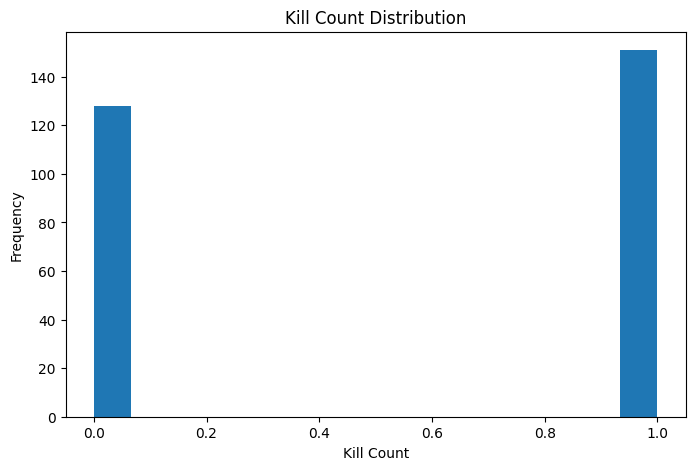

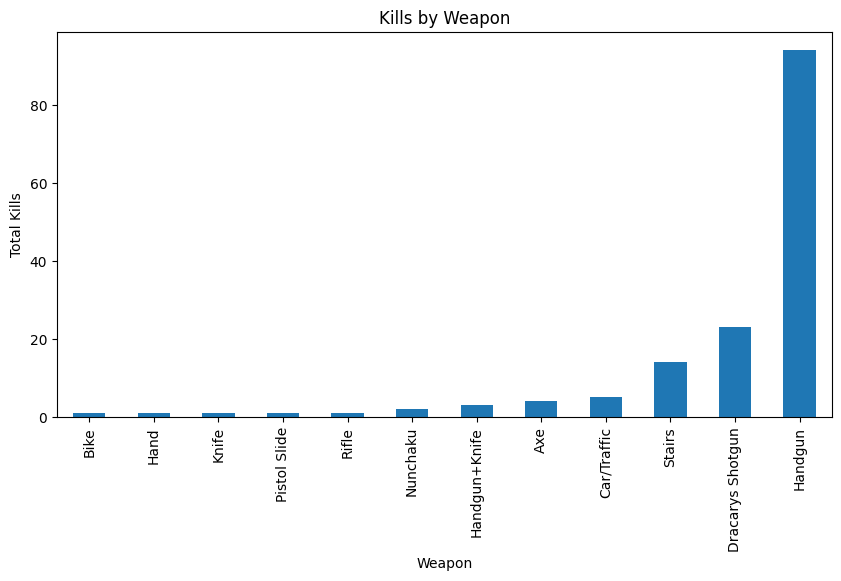

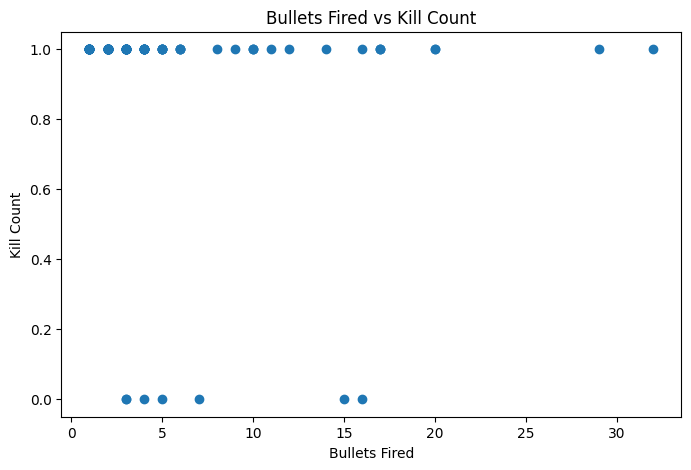

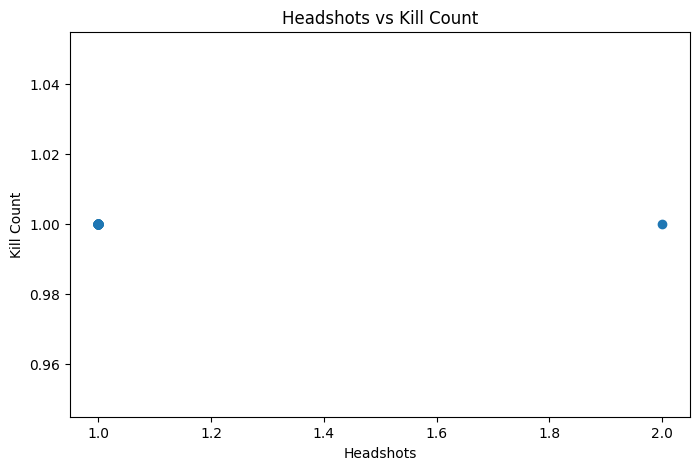


Decision Tree
RMSE: 0.0
MAE: 0.0
R2: 1.0

Bagging
RMSE: 0.004008918628686369
MAE: 0.0005357142857142862
R2: 0.9999353846153847

Random Forest
RMSE: 0.012026755886059093
MAE: 0.0016071428571428567
R2: 0.9994184615384616
OOB Score: 0.9977413540931643
OOB Error: 0.0022586459068356657

Bootstrap Sampling
Original Samples: 223
Bootstrap Samples: 223
Unique Samples: 138
OOB Samples: 85

Feature Subsampling
max_features = sqrt | OOB Score = 0.9977
max_features = log2 | OOB Score = 0.9977
max_features = 0.5 | OOB Score = 0.9966
max_features = 1.0 | OOB Score = 0.9969

Feature Importance:
 Where                  0.384571
Who                    0.370418
Weapon                 0.204617
Minute                 0.030935
Bullets_Fired          0.009094
Injury_Sustained       0.000364
Headshots              0.000000
Sum_Target_Hit         0.000000
Count_Target_Missed    0.000000
dtype: float64


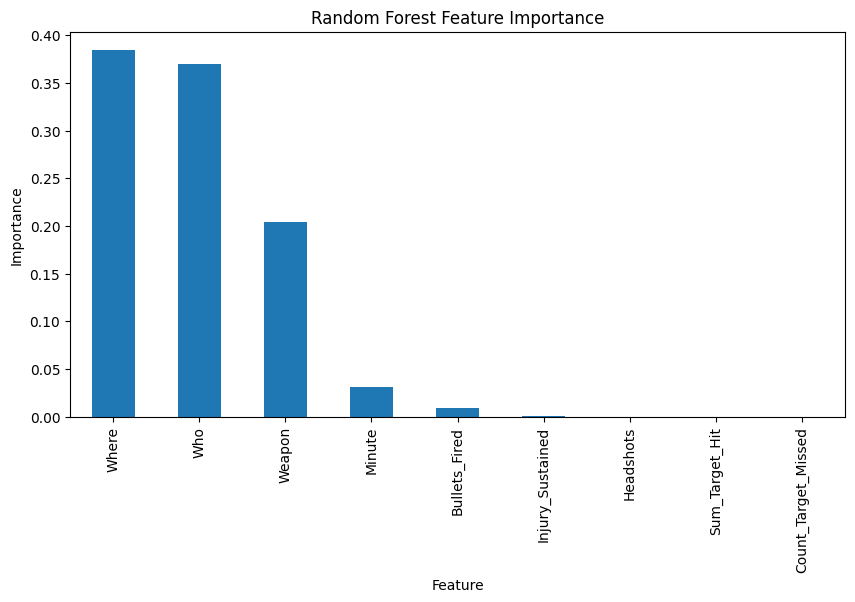

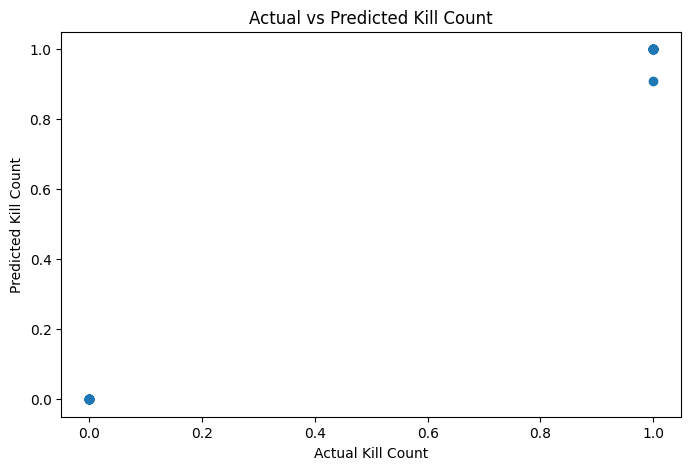


Model Comparison:
            Model      RMSE       MAE        R2
0  Decision Tree  0.000000  0.000000  1.000000
1        Bagging  0.004009  0.000536  0.999935
2  Random Forest  0.012027  0.001607  0.999418


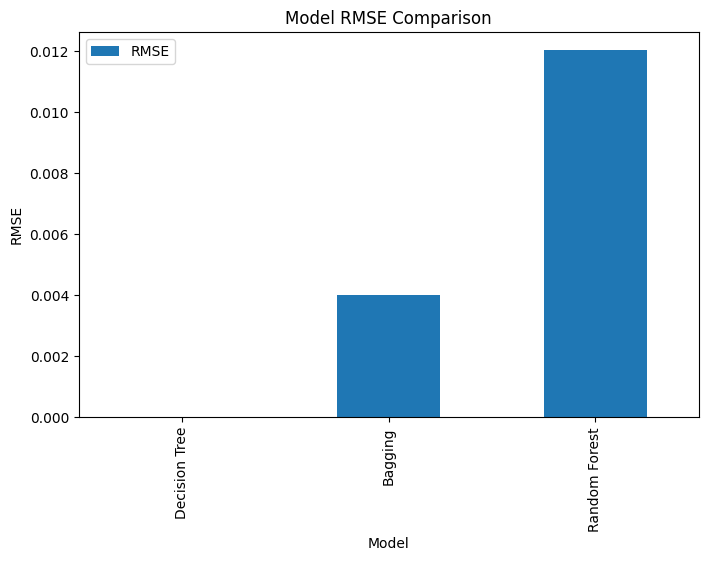

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
!pip -q install -U fg-data-profiling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from data_profiling import ProfileReport
from google.colab import files

df = pd.read_csv("John_Wick_4_Kill_Count.csv")

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nStatistics:\n", df.describe())

report = ProfileReport(df, title="John Wick 4 Kill Count EDA")
report.to_file("John_Wick_EDA_Report.html")

plt.figure(figsize=(8,5))
plt.hist(df["Kill Count"].dropna(), bins=15)
plt.xlabel("Kill Count")
plt.ylabel("Frequency")
plt.title("Kill Count Distribution")
plt.show()

df.groupby("Weapon")["Kill Count"].sum().sort_values().plot(kind="bar", figsize=(10,5))
plt.xlabel("Weapon")
plt.ylabel("Total Kills")
plt.title("Kills by Weapon")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["Bullets_Fired"], df["Kill Count"])
plt.xlabel("Bullets Fired")
plt.ylabel("Kill Count")
plt.title("Bullets Fired vs Kill Count")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(df["Headshots"], df["Kill Count"])
plt.xlabel("Headshots")
plt.ylabel("Kill Count")
plt.title("Headshots vs Kill Count")
plt.show()

df = df.dropna(subset=["Kill Count"])

X = df.drop("Kill Count", axis=1)
y = df["Kill Count"]

for column in X.select_dtypes(include="object").columns:
    X[column] = LabelEncoder().fit_transform(X[column].astype(str))

X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tree = DecisionTreeRegressor(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
tree_pred = tree.predict(X_test)

bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=100,
    bootstrap=True,
    random_state=42
)
bagging.fit(X_train, y_train)
bag_pred = bagging.predict(X_test)

rf = RandomForestRegressor(
    n_estimators=100,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
bag_rmse = np.sqrt(mean_squared_error(y_test, bag_pred))
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

tree_mae = mean_absolute_error(y_test, tree_pred)
bag_mae = mean_absolute_error(y_test, bag_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

tree_r2 = r2_score(y_test, tree_pred)
bag_r2 = r2_score(y_test, bag_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("\nDecision Tree")
print("RMSE:", tree_rmse)
print("MAE:", tree_mae)
print("R2:", tree_r2)

print("\nBagging")
print("RMSE:", bag_rmse)
print("MAE:", bag_mae)
print("R2:", bag_r2)

print("\nRandom Forest")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2:", rf_r2)
print("OOB Score:", rf.oob_score_)
print("OOB Error:", 1 - rf.oob_score_)

sample = X_train.sample(len(X_train), replace=True, random_state=42)

print("\nBootstrap Sampling")
print("Original Samples:", len(X_train))
print("Bootstrap Samples:", len(sample))
print("Unique Samples:", sample.index.nunique())
print("OOB Samples:", len(X_train) - sample.index.nunique())

print("\nFeature Subsampling")

for value in ["sqrt", "log2", 0.5, 1.0]:
    model = RandomForestRegressor(
        n_estimators=100,
        max_features=value,
        bootstrap=True,
        oob_score=True,
        random_state=42
    )
    model.fit(X_train, y_train)
    print("max_features =", value, "| OOB Score =", round(model.oob_score_, 4))

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance:\n", importance)

importance.plot(kind="bar", figsize=(10,5))
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Kill Count")
plt.ylabel("Predicted Kill Count")
plt.title("Actual vs Predicted Kill Count")
plt.show()

results = pd.DataFrame({
    "Model": ["Decision Tree", "Bagging", "Random Forest"],
    "RMSE": [tree_rmse, bag_rmse, rf_rmse],
    "MAE": [tree_mae, bag_mae, rf_mae],
    "R2": [tree_r2, bag_r2, rf_r2]
})

print("\nModel Comparison:\n", results)

results.plot(x="Model", y="RMSE", kind="bar", figsize=(8,5))
plt.ylabel("RMSE")
plt.title("Model RMSE Comparison")
plt.show()

results.to_csv("John_Wick_Model_Results.csv", index=False)
importance.to_csv("John_Wick_Feature_Importance.csv")

files.download("John_Wick_EDA_Report.html")
files.download("John_Wick_Model_Results.csv")
files.download("John_Wick_Feature_Importance.csv")